In [1]:
import sys
import os
import os.path as osp
print(sys.executable)

import mmcv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from nuscenes.eval.detection.config import config_factory
from nuscenes.eval.detection.evaluate import DetectionEval

from mmdet3d.unibev_plugin.datasets import DetectionEvalVis
from nuscenes.utils.splits import val, mini_val
from nuscenes.nuscenes import NuScenes
# os.chdir('/tudelft.net/staff-bulk/3me/cor/IV/swang/hpc/workspace/mmdet3d_prev')
os.chdir('/home/mingdayang/mmdetection3d/')

/home/mingdayang/miniconda3/envs/unibev/bin/python


## Define the path

In [2]:
data_root = 'data/nuscenes/'
iv_mind_output_dir = 'outputs/inference'
daic_output_dir = 'remote_mounted/daic_outputs/inference'

vis_results = dict(
    unibev_nus_LC_cnw_256_modality_dropout_mininuscene_ivmind = 'unibev_nus_LC_cnw_256_modality_dropout_mininuscene',
    )

unibev_LC = vis_results['unibev_nus_LC_cnw_256_modality_dropout_mininuscene_ivmind']

In [3]:
nusc = NuScenes(version='v1.0-mini', dataroot=data_root, verbose=True)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.547 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [4]:
eval_set = 'mini_val'
eval_detect_configs = config_factory('detection_cvpr_2019')

In [5]:
for vis_modal in vis_results.keys():
    if 'ivmind' in vis_modal:
        print('ivmind')
        json_file = osp.join(iv_mind_output_dir, vis_results[vis_modal], 'pts_bbox', 'results_nusc.json')
    else:
        print('hpc')
        json_file = osp.join(daic_output_dir, vis_results[vis_modal], 'pts_bbox', 'results_nusc.json')

ivmind


In [6]:
results_output_dir = f'/tmp/nuscenes_vis/qualitative/{vis_modal}'

nusc_eval = DetectionEvalVis(
    nusc = nusc,
    config=eval_detect_configs,
    result_path=json_file,
    eval_set=eval_set,
    output_dir=results_output_dir,
    verbose=True)



Initializing nuScenes detection evaluation
Loaded results from outputs/inference/unibev_nus_LC_cnw_256_modality_dropout_mininuscene/pts_bbox/results_nusc.json. Found detections for 81 samples.
Loading annotations for mini_val split from nuScenes version: v1.0-mini


100%|██████████| 81/81 [00:00<00:00, 280.43it/s]


Loaded ground truth annotations for 81 samples.
Filtering predictions
=> Original number of boxes: 19305
=> After distance based filtering: 19302
=> After LIDAR and RADAR points based filtering: 19302
=> After bike rack filtering: 19226
Filtering ground truth annotations
=> Original number of boxes: 4441
=> After distance based filtering: 3785
=> After LIDAR and RADAR points based filtering: 3393
=> After bike rack filtering: 3393


In [7]:
print(nusc_eval.cfg.dist_ths)
print(nusc_eval.cfg.dist_th_tp)
print(nusc_eval.cfg.dist_fcn)

[0.5, 1.0, 2.0, 4.0]
2.0
center_distance


## Visualize a single sample

### With imporved EvalVis

In [8]:
import matplotlib.pyplot as plt

Rendering sample token 3e8750f331d7499e9b5123e9eb70f2e2
Width: 106.0 units, Height: 106.0 units


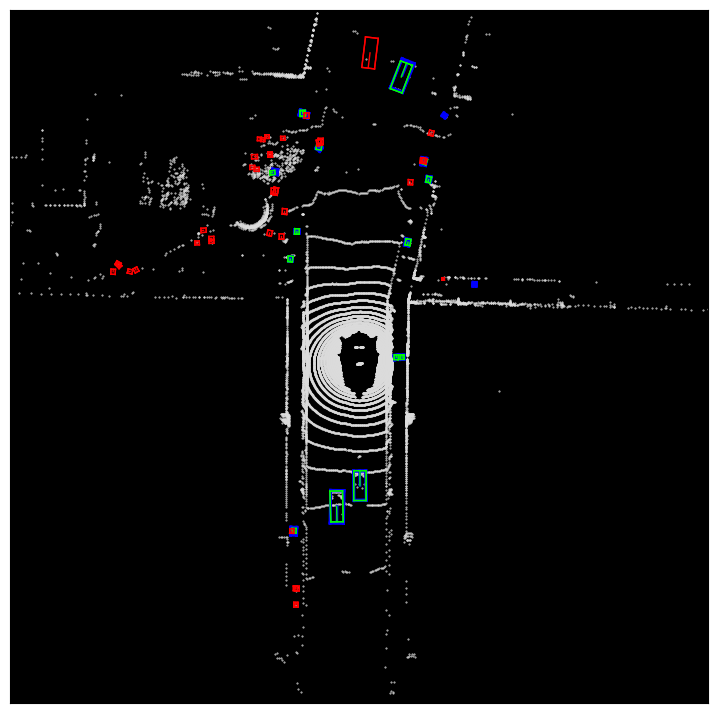

In [9]:
%matplotlib inline
sample_token = '3e8750f331d7499e9b5123e9eb70f2e2' 
fig = nusc_eval.main_vis_per_sample(sample_token, conf_th=0.15, with_GT = True)


ax = fig.gca()
x_min, x_max = ax.get_xlim()  # Horizontal axis (width)
y_min, y_max = ax.get_ylim() 

# Print the width and height in data units
width = x_max - x_min
height = y_max - y_min

print(f"Width: {width} units, Height: {height} units")
fig

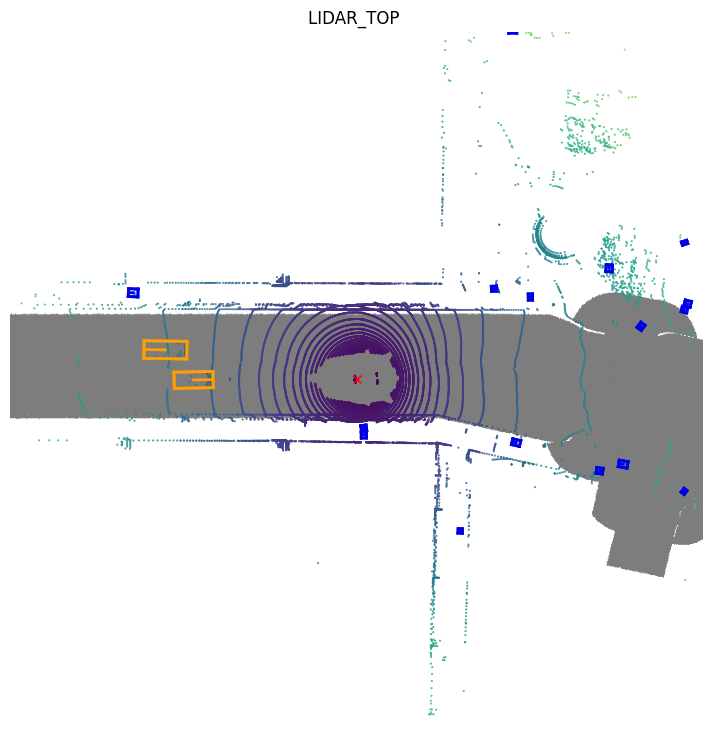

In [10]:
%matplotlib inline
my_sample = nusc.get('sample', sample_token)
fig2 = nusc.render_sample_data(my_sample['data']['LIDAR_TOP'], nsweeps=40, underlay_map=True)
fig2

In [25]:
def load_lidar_data(file_name, data_root=""):
    # Construct the file path based on your sample token
    lidar_file_path = os.path.join(data_root, f"{file_name}")  # Update as needed
    if not os.path.exists(lidar_file_path):
        raise FileNotFoundError(f"Lidar file not found: {lidar_file_path}")

    # Load the LiDAR points from the binary file
    lidar_points = np.fromfile(lidar_file_path, dtype=np.float32).reshape([-1, 5])  # Assuming the format is (x, y, z, intensity)

    # Extracting x, y, z coordinates; you can also get intensity if needed
    return lidar_points[:, :5]  # Returns only the (x, y, z) coordinates

def plot_lidar_points_bev(lidar_points):
    # Assuming lidar_points is an Nx5 array where each row is (x, y, z, intensity, ring index)
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Extract x and y coordinates
    x = lidar_points[:, 0]
    y = lidar_points[:, 1]
    z = lidar_points[:, 2]
    
    # Calculate the distance from the center (0, 0)
    distances = np.sqrt(x**2 + y**2)

    # Normalize distance values for color mapping
    norm = plt.Normalize(distances.min(), distances.max())
    
    # Map distance values to colors using a colormap (e.g., 'plasma')
    colors = cm.plasma(norm(distances))

    # Scatter plot of LiDAR points in BEV (X vs Y) with color based on distance
    scatter = ax.scatter(x, y, c=colors, marker='.', s=1)

    # Set limits for the axes
    ax.set_xlim(-50, 50)
    ax.set_ylim(-50, 50)

    # Set labels
    ax.set_xlabel('X (Forward/Backward)')
    ax.set_ylabel('Y (Left/Right)')
    ax.set_title('Bird\'s Eye View of LiDAR Points')

    # Set aspect of the plot to be equal
    ax.set_aspect('equal', adjustable='box')

    # Add a colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Distance from Center')

    plt.grid()
    plt.show()


def plot_lidar_points_bev_multi(lidar_points1, lidar_points2):
    # Assuming lidar_points1 and lidar_points2 are Nx5 arrays where each row is (x, y, z, intensity, ring index)
    
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))  # 1 colum, 2 rows
    
    for i, lidar_points in enumerate([lidar_points1, lidar_points2]):
        # Extract x and y coordinates
        x = lidar_points[:, 0]
        y = lidar_points[:, 1]
        z = lidar_points[:, 2]
        
        # Calculate the distance from the center (0, 0)
        distances = np.sqrt(x**2 + y**2)

        # Normalize distance values for color mapping
        norm = plt.Normalize(distances.min(), distances.max())
        
        # Map distance values to colors using a colormap (e.g., 'plasma')
        colors = cm.plasma(norm(distances))

        # Scatter plot of LiDAR points in BEV (X vs Y) with color based on distance
        scatter = axs[i].scatter(x, y, c=colors, marker='.', s=1)

        # Set limits for the axes
        axs[i].set_xlim(-50, 50)
        axs[i].set_ylim(-50, 50)

        # Set labels
        axs[i].set_xlabel('X (Forward/Backward)')
        axs[i].set_ylabel('Y (Left/Right)')
        axs[i].set_title(f'Bird\'s Eye View of LiDAR Points {i + 1}')

        # Set aspect of the plot to be equal
        axs[i].set_aspect('equal', adjustable='box')

        # Add a colorbar
        cbar = plt.colorbar(scatter, ax=axs[i])
        cbar.set_label('Distance from Center')

        axs[i].grid()

    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

In [28]:
file_name = "/home/mingdayang/mmdetection3d/data/nuscenes/sweeps/LIDAR_TOP/n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151604998006.pcd.bin"
lidar_points = load_lidar_data(file_name)
print(lidar_points)
print(f"beam_id_unique: {np.unique(lidar_points[:,-2], return_counts=True)}")

[[-3.1070001e+00 -4.1143340e-01 -1.8747313e+00  4.0000000e+00
   0.0000000e+00]
 [-3.2712109e+00 -4.1055000e-01 -1.8703160e+00  4.0000000e+00
   1.0000000e+00]
 [-3.4842806e+00 -4.1012198e-01 -1.8851714e+00  6.0000000e+00
   2.0000000e+00]
 ...
 [ 1.9708690e-05 -3.6213551e-05 -2.5892343e-06  5.0000000e+00
   2.9000000e+01]
 [ 1.9708690e-05 -3.6213551e-05 -2.5892343e-06  1.8000000e+01
   3.0000000e+01]
 [ 1.9708690e-05 -3.6213551e-05 -2.5892343e-06  3.0000000e+01
   3.1000000e+01]]
beam_id_unique: (array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.

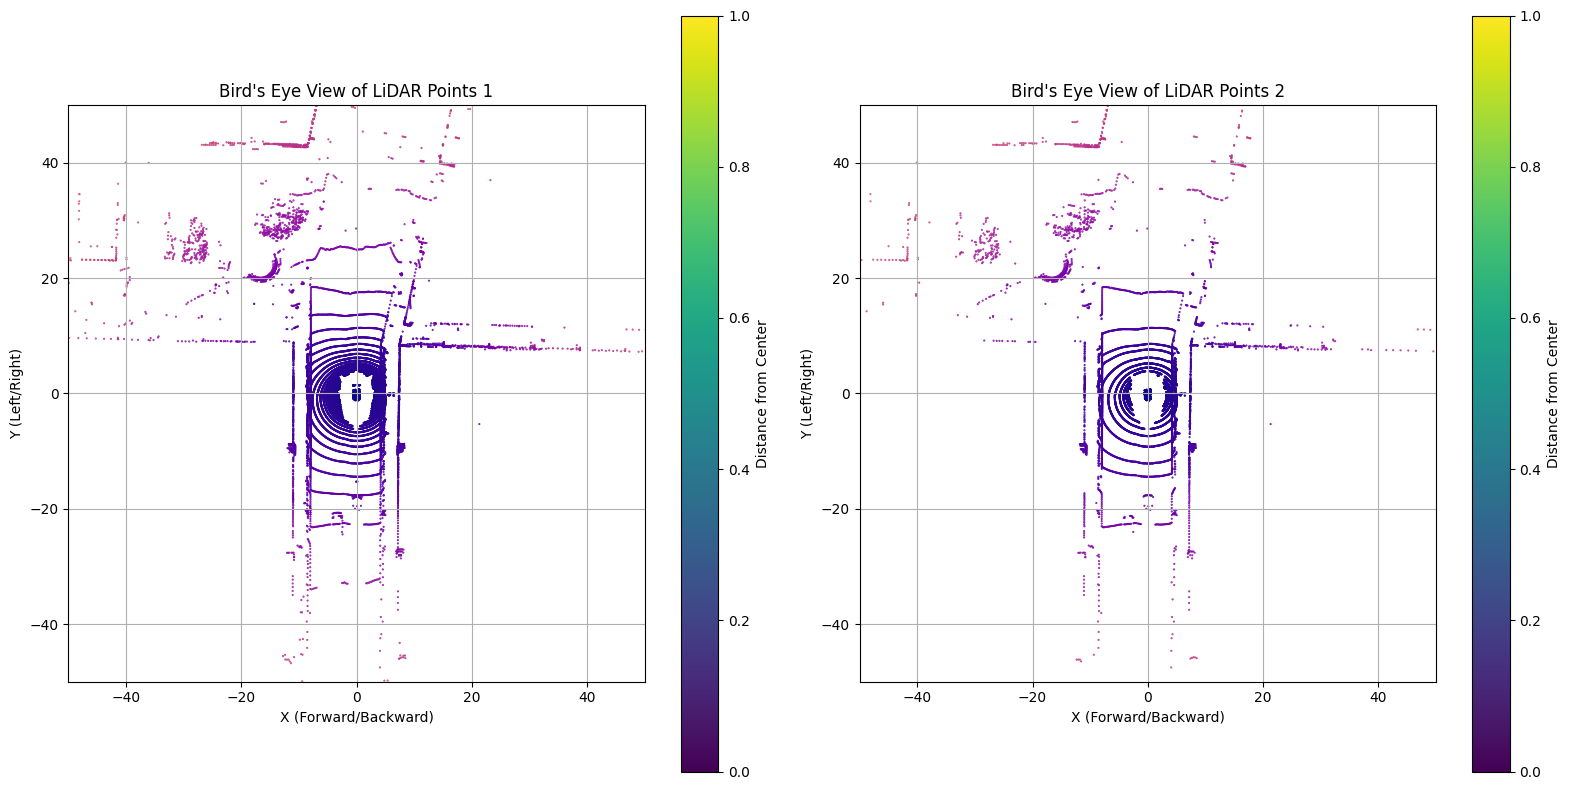

In [12]:
file_name = "n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151603547590.pcd.bin" # Sample lidar data
# file_name = "n008-2018-08-01-15-52-19-0400__LIDAR_TOP__1533153749847581.pcd.bin" # Sweep lidar data
data_root3 = "/home/mingdayang/mmdetection3d/save_root/beam_missing/24beam/sweeps/LIDAR_TOP/" 
data_root = "/home/mingdayang/mmdetection3d/save_root/beam_missing/24beam/samples/LIDAR_TOP/"
data_root_original = "/home/mingdayang/mmdetection3d/data/nuscenes/samples/LIDAR_TOP/"
data_root_16 = "/home/mingdayang/mmdetection3d/save_root/beam_missing/16beam/samples/LIDAR_TOP/"
# lidar_points = load_lidar_data(file_name, data_root)
# lidar_points2 = load_lidar_data(file_name, data_root2)
# plot_lidar_points_bev(load_lidar_data(file_name, data_root3))
lidar_points_full_beams = load_lidar_data(file_name, data_root_original)
lidar_points_missing_16 = load_lidar_data(file_name, data_root_16)
plot_lidar_points_bev_multi(lidar_points_full_beams, lidar_points_missing_16)

In [13]:
import numpy as np

target_timestamp = 1533151603547590 # Replace with your desired timestamp

# Initialize variables to track the closest sample
closest_sample_token = None
closest_time_diff = float('inf')

# Iterate through all scenes
for scene in nusc.scene:
    # Start from the first sample of the scene
    current_sample_token = scene['first_sample_token']

    while current_sample_token:
        # Retrieve the sample
        sample = nusc.get('sample', current_sample_token)

        # Calculate the time difference between the sample and the target timestamp
        time_diff = abs(sample['timestamp'] - target_timestamp)

        # Check for an exact match
        if sample['timestamp'] == target_timestamp:
            closest_sample_token = current_sample_token
            closest_time_diff = 0
            break

        # Update closest sample if this sample is closer
        if time_diff < closest_time_diff:
            closest_sample_token = current_sample_token
            closest_time_diff = time_diff

        # Move to the next sample in the scene
        current_sample_token = sample['next']

    # Break if we found an exact match
    if closest_time_diff == 0:
        break

# Output the closest sample token and time difference
if closest_sample_token:
    print(f"Closest sample token: {closest_sample_token}")
    print(f"Time difference (microseconds): {closest_time_diff}")
else:
    print("No matching sample token found.")

Closest sample token: 3e8750f331d7499e9b5123e9eb70f2e2
Time difference (microseconds): 0


In [16]:
num_beam_to_drop = 24
print(32//num_beam_to_drop)
to_drop = np.arange(0, 32, 32//num_beam_to_drop)[0:num_beam_to_drop]
print(to_drop)
print(np.size(to_drop))

1
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
24


In [49]:
total_beams = 32
num_beam_to_drop = 16
step = int(np.ceil(total_beams/(total_beams-num_beam_to_drop)))
print(step)
to_keep = np.arange(0, total_beams+1, step)
print(to_keep)
print(len(to_keep))
to_drop = np.setdiff1d(np.arange(total_beams), to_keep)
print(to_drop)
print(len(to_drop))

2
[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32]
17
[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31]
16


In [50]:
print(np.linspace(0, total_beams, num_beam_to_drop, dtype=int))

[ 0  2  4  6  8 10 12 14 17 19 21 23 25 27 29 32]
